In [1]:
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Computer Vision Library
import cv2

# glob
from glob import glob

In [2]:
# Extract the paths of the images in cropped data
fpath = glob('../crop_faces/females/*.jpg')
mpath = glob('../crop_faces/males/*.jpg')

In [3]:
# Create DataFrames for the images
df_females = pd.DataFrame(fpath, columns=['filepath'])
df_females['gender'] = 'female'

df_males = pd.DataFrame(mpath, columns=['filepath'])
df_males['gender'] = 'male'

df_images = pd.concat((df_females, df_males), axis=0)

In [4]:
df_images.head()

,filepath,gender
0,../crop_faces/females\female_0.jpg,female
1,../crop_faces/females\female_1.jpg,female
2,../crop_faces/females\female_100.jpg,female
3,../crop_faces/females\female_1002.jpg,female
4,../crop_faces/females\female_1005.jpg,female


In [5]:
df_images.tail()

,filepath,gender
2170,../crop_faces/males\male_994.jpg,male
2171,../crop_faces/males\male_996.jpg,male
2172,../crop_faces/males\male_997.jpg,male
2173,../crop_faces/males\male_998.jpg,male
2174,../crop_faces/males\male_999.jpg,male


In [6]:
df_images.shape[0]

4761

In [7]:
# Take each image path then return width of the image
def get_size(path):
    img = cv2.imread(path)
    return img.shape[0]

In [8]:
df_images['dimension'] = df_images['filepath'].apply(get_size)

## Distribution of the males and females
    Bar Chart
    Pie Chart

In [9]:
dist_gender = df_images['gender'].value_counts()
dist_gender

gender
female    2586
male      2175
Name: count, dtype: int64

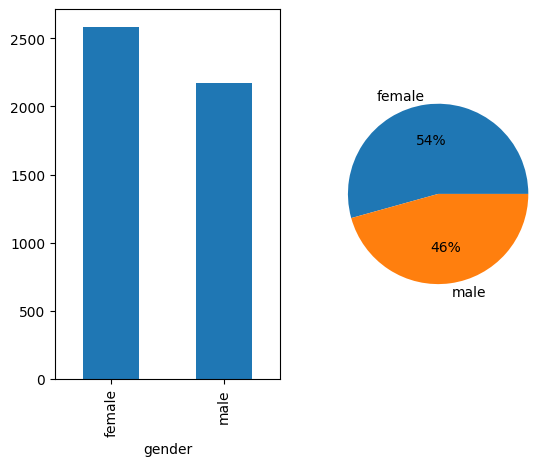

In [10]:
fig, ax = plt.subplots(nrows=1, ncols=2)
dist_gender.plot(kind='bar', ax=ax[0])
dist_gender.plot(kind='pie', ax=ax[1], autopct='%0.0f%%')
plt.show()

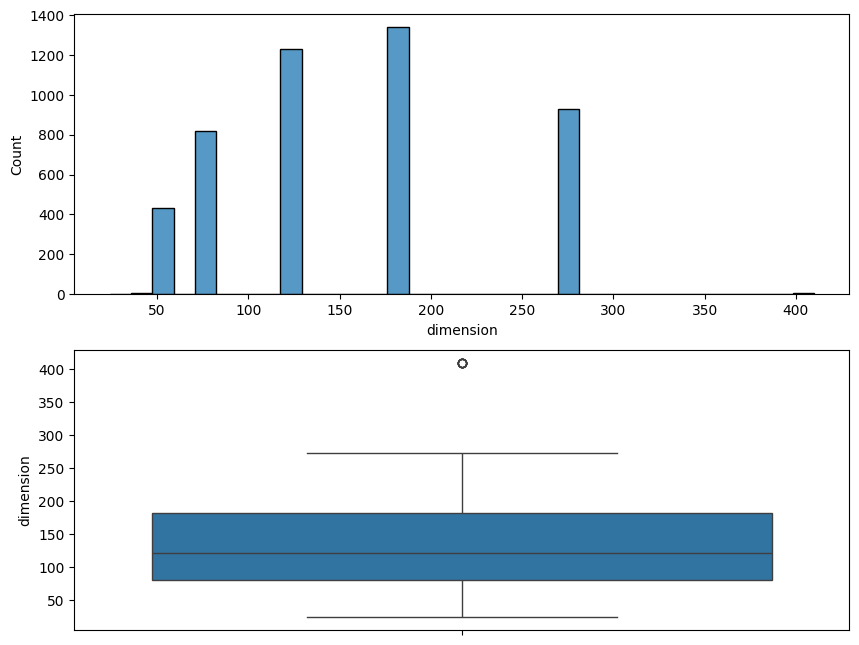

In [11]:
plt.figure(figsize=(10, 8))
plt.subplot(2,1,1)
sns.histplot(df_images['dimension'])
plt.subplot(2,1,2)
sns.boxplot(df_images['dimension'])
plt.show()

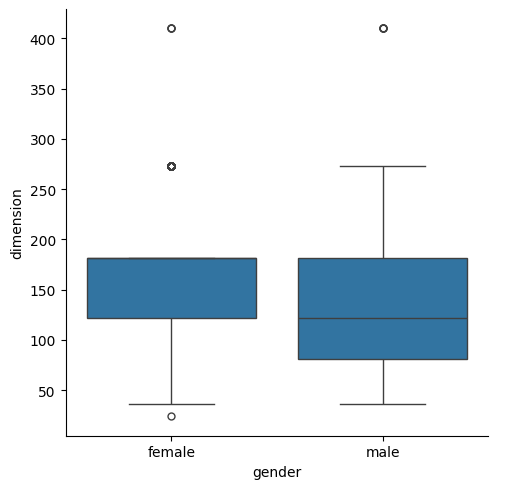

In [12]:
sns.catplot(data=df_images, x='gender', y='dimension', kind='box');

1. We have almost all images equal distribution of gender (numbers)
2. Most of the images are having dimension more than 60
3. Female images are high dimensions compare to male images

----
**Consider the images with dimensions more than 60**

**Resize all the images into 100 x 100**

In [15]:
df_images_filter = df_images.query('dimension > 60')

In [16]:
df_images_filter

,filepath,gender,dimension
0,../crop_faces/females\female_0.jpg,female,273
1,../crop_faces/females\female_1.jpg,female,182
2,../crop_faces/females\female_100.jpg,female,122
3,../crop_faces/females\female_1002.jpg,female,122
4,../crop_faces/females\female_1005.jpg,female,182
...,...,...,...
2168,../crop_faces/males\male_991.jpg,male,273
2170,../crop_faces/males\male_994.jpg,male,122
2172,../crop_faces/males\male_997.jpg,male,122
2173,../crop_faces/males\male_998.jpg,male,81


In [17]:
df_images_filter.shape

(4322, 3)

In [18]:
df_images_filter['gender'].value_counts(normalize=True)

gender
female    0.552059
male      0.447941
Name: proportion, dtype: float64

In [19]:
def resize_img(path):
    try:
        # Step 1 - Read image
        img = cv2.imread(path)
    
        # step 2 - Convert the image to grayscale
        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    
        # Step 3 - Resize to 100 x 100 array
        size = gray.shape[0]
        if size >= 100:
            gray_resize = cv2.resize(gray, (100, 100), cv2.INTER_AREA)
        else:
            gray_resize = cv2.resize(gray, (100, 100), cv2.INTER_CUBIC)
    
        # step 4 - Flatten the image
        return gray_resize.flatten()
    except:
        return None

In [21]:
df_images_filter['data'] = df_images_filter['filepath'].apply(resize_img)

In [22]:
df_images_filter.head()

,filepath,gender,dimension,data
0,../crop_faces/females\female_0.jpg,female,273,"[200, 189, 188, 181, 184, 185, 179, 176, 189, ..."
1,../crop_faces/females\female_1.jpg,female,182,"[31, 25, 35, 25, 31, 29, 30, 31, 34, 34, 49, 7..."
2,../crop_faces/females\female_100.jpg,female,122,"[49, 49, 35, 34, 42, 40, 35, 39, 71, 62, 46, 4..."
3,../crop_faces/females\female_1002.jpg,female,122,"[137, 128, 114, 96, 96, 95, 93, 114, 150, 163,..."
4,../crop_faces/females\female_1005.jpg,female,182,"[234, 236, 231, 231, 231, 185, 142, 111, 52, 4..."


In [23]:
data = df_images_filter['data'].apply(pd.Series)

In [24]:
data.columns = [f'pixel_{i}' for i in data.columns]

In [25]:
data.head()

,pixel_0,pixel_1,pixel_2,pixel_3,pixel_4,pixel_5,pixel_6,pixel_7,pixel_8,pixel_9,...,pixel_9990,pixel_9991,pixel_9992,pixel_9993,pixel_9994,pixel_9995,pixel_9996,pixel_9997,pixel_9998,pixel_9999
0,200,189,188,181,184,185,179,176,189,180,...,109,106,108,111,113,115,120,117,118,122
1,31,25,35,25,31,29,30,31,34,34,...,45,27,22,30,22,35,20,35,65,19
2,49,49,35,34,42,40,35,39,71,62,...,210,230,231,237,238,230,220,212,210,208
3,137,128,114,96,96,95,93,114,150,163,...,66,53,68,67,74,92,97,103,102,96
4,234,236,231,231,231,185,142,111,52,45,...,241,240,236,237,239,237,237,242,241,241


### Data Normalization

In [26]:
data = data/255.0

In [27]:
data['gender'] = df_images_filter['gender']

In [28]:
data.head()

,pixel_0,pixel_1,pixel_2,pixel_3,pixel_4,pixel_5,pixel_6,pixel_7,pixel_8,pixel_9,...,pixel_9991,pixel_9992,pixel_9993,pixel_9994,pixel_9995,pixel_9996,pixel_9997,pixel_9998,pixel_9999,gender
0,0.784314,0.741176,0.737255,0.709804,0.721569,0.725490,0.701961,0.690196,0.741176,0.705882,...,0.415686,0.423529,0.435294,0.443137,0.450980,0.470588,0.458824,0.462745,0.478431,female
1,0.121569,0.098039,0.137255,0.098039,0.121569,0.113725,0.117647,0.121569,0.133333,0.133333,...,0.105882,0.086275,0.117647,0.086275,0.137255,0.078431,0.137255,0.254902,0.074510,female
2,0.192157,0.192157,0.137255,0.133333,0.164706,0.156863,0.137255,0.152941,0.278431,0.243137,...,0.901961,0.905882,0.929412,0.933333,0.901961,0.862745,0.831373,0.823529,0.815686,female
3,0.537255,0.501961,0.447059,0.376471,0.376471,0.372549,0.364706,0.447059,0.588235,0.639216,...,0.207843,0.266667,0.262745,0.290196,0.360784,0.380392,0.403922,0.400000,0.376471,female
4,0.917647,0.925490,0.905882,0.905882,0.905882,0.725490,0.556863,0.435294,0.203922,0.176471,...,0.941176,0.925490,0.929412,0.937255,0.929412,0.929412,0.949020,0.945098,0.945098,female


In [29]:
data.tail()

,pixel_0,pixel_1,pixel_2,pixel_3,pixel_4,pixel_5,pixel_6,pixel_7,pixel_8,pixel_9,...,pixel_9991,pixel_9992,pixel_9993,pixel_9994,pixel_9995,pixel_9996,pixel_9997,pixel_9998,pixel_9999,gender
2168,0.470588,0.372549,0.431373,0.329412,0.396078,0.600000,0.447059,0.568627,0.631373,0.643137,...,0.458824,0.486275,0.494118,0.509804,0.537255,0.537255,0.525490,0.482353,0.439216,male
2170,0.062745,0.070588,0.066667,0.062745,0.066667,0.062745,0.054902,0.058824,0.062745,0.074510,...,0.898039,0.909804,0.913725,0.917647,0.921569,0.921569,0.917647,0.913725,0.909804,male
2172,0.694118,0.701961,0.705882,0.709804,0.709804,0.713725,0.717647,0.717647,0.709804,0.705882,...,0.560784,0.552941,0.537255,0.545098,0.564706,0.592157,0.619608,0.650980,0.674510,male
2173,0.145098,0.145098,0.145098,0.145098,0.149020,0.156863,0.156863,0.152941,0.152941,0.152941,...,0.160784,0.172549,0.188235,0.211765,0.239216,0.262745,0.278431,0.282353,0.278431,male
2174,0.713725,0.717647,0.721569,0.721569,0.717647,0.725490,0.721569,0.721569,0.725490,0.721569,...,0.643137,0.682353,0.741176,0.745098,0.749020,0.745098,0.745098,0.745098,0.745098,male


### Remove missing values

In [32]:
data.isnull().sum().sum()

np.int64(0)

In [33]:
data.dropna(inplace=True)

In [34]:
data.shape

(4322, 10001)

### Save Data using pickle and save in the data folder

In [36]:
import pickle

In [37]:
pickle.dump(data, open('../data/data_images_100_100.pickle', mode='wb'))